# Práctica #2 - Parte 1


### Resumen 
## Procesamiento de señales biomédicas

El procesamiento de señales biomédicas requirió el uso de herramientas especializadas en Python y métricas estadísticas fundamentales para caracterizar los registros analizados.

### Bibliotecas de Python

- **NumPy:** Soporte para el manejo de vectores y arreglos multidimensionales, facilitando operaciones matemáticas de alto rendimiento.

- **Pandas:** Estructuración, manipulación y análisis de datos mediante tablas dinámicas y marcos de datos (*DataFrames*).

- **SciPy:** Módulos de cálculo científico avanzado para el procesamiento digital de señales y la carga de archivos de entorno MATLAB.

- **Matplotlib:** Generación de gráficos bidimensionales para visualizar la evolución temporal de las señales.

- **Seaborn:** Visualización de datos estadísticos basada en Matplotlib, con estilos de trazado optimizados y de alto nivel.

### Parámetros estadísticos y de señal

- **Promedio (Media):** Suma de todos los datos dividida entre el número total de muestras; representa el valor de tendencia central de la señal.

- **Varianza:** Promedio de las diferencias al cuadrado respecto a la media; mide qué tan dispersos o alejados están los datos de su valor central.

- **Desviación estándar:** Raíz cuadrada de la varianza; cuantifica la dispersión de los datos conservando la misma unidad de medida de la señal original.

- **RMS (*Root Mean Square* / Valor eficaz):** Mide la energía o potencia acumulada de una señal oscilante calculando la raíz cuadrada del promedio de los datos al cuadrado:

$$
\text{RMS} = \sqrt{\frac{1}{N}\sum_{i=1}^{N}x_i^2}
$$

### Procesamiento de la señal

Durante el desarrollo se pudo evidenciar la importancia de eliminar el ruido de la señal, con el fin de obtener valores representativos y realizar un análisis adecuado de los ciclos cardíacos.

### Pruebas estadísticas

**Prueba *t* de Student:** Prueba paramétrica empleada para determinar si existen diferencias estadísticamente significativas entre las medias de dos grupos.

#### Supuestos de la prueba *t*

- **Escala continua:** La variable analizada debe medirse en una escala cuantitativa de intervalo o razón.
- **Independencia:** Las observaciones de cada muestra deben ser independientes entre sí.
- **Normalidad:** La distribución de los datos en ambos grupos debe aproximarse a una distribución normal.
- **Homocedasticidad:** Las varianzas de los dos grupos comparados deben ser homogéneas o similares.

**Prueba U de Mann-Whitney:** Alternativa no paramétrica a la prueba *t* para dos muestras independientes. Compara los rangos de los datos y resulta útil cuando no se cumple el supuesto de normalidad.

**Prueba de Dickey-Fuller:** Prueba utilizada en series temporales para detectar la presencia de una raíz unitaria, permitiendo evaluar si una señal es estacionaria o si sus propiedades estadísticas varían a lo largo del tiempo.

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.stats as stats
from statistics import mean
import scipy.io
from scipy.signal import find_peaks
from statsmodels.tsa.stattools import adfuller

#### Implementación de funciones
- Se crea una función rms, donde en el argumento se ingresa la señal de la cual se pretende obtener el valor.

In [2]:
y= 3*np.sin(2*np.pi*1*np.linspace(0, 1, 1000)) + 0.5*np.random.randn(1000)

# RMS de cada señal
def rms(signal):
    return np.sqrt(np.mean(signal**2))

RMS1 = rms(y)

print("RMS Voluntario 1:", RMS1)

RMS Voluntario 1: 2.177232186936168


- ahora se seleccione un ciclo cardiaco de la señal y se grafica. Luego calculamos el promedio, el valor RMS, la varianza y la desviación estándar del ciclo.

In [ ]:
datos = scipy.io.loadmat("signals.mat")
print(datos)
# 1. Extraer y forzar a que sean vectores de 1 dimensión (1D)
senal_original = np.squeeze(datos["ECG_asRecording"]) # Verifica que la llave sea la correcta
senal_filtrada = np.squeeze(datos["ECG_filtered"])

# 2. Obtener la cantidad exacta de puntos
N_original = len(senal_original)
N_filtrada = len(senal_filtrada)
Fs = 1024
# 3. Crear los vectores de tiempo 
t = np.arange(N_original) / Fs
t_filtrada = np.arange(N_filtrada) / Fs

print(f"La señal filtrada dura {N_filtrada} segundos")
print(f"La señal original dura {N_original} segundos")


{'__header__': b'MATLAB 5.0 MAT-file, Platform: GLNXA64, Created on: Mon Apr 20 15:20:29 2015', '__version__': '1.0', '__globals__': [], 'Fs': array([[1024]], dtype=uint16), 'ECG_asRecording': array([[3904.31689453, 3939.203125  , 3976.00683594, ..., 4366.41064453,
        4365.31103516, 4370.91796875]], shape=(1, 30720)), 'ECG_filtered': array([[ 8.87103896e-03,  5.62737497e+01,  8.57077127e+01, ...,
        -1.20952610e+02, -1.31734356e+02, -1.32898021e+02]],
      shape=(1, 30720)), 'EMG_filtered1': array([[ 17.65905117,  19.41391578,  18.89666666, ..., 242.49414224,
        220.4135886 , 151.5810508 ]], shape=(1, 30721)), 'EMG_filtered2': array([[  21.1780547 ,  -79.82418538, -133.65960989, ..., -384.58994036,
        -539.9349533 , -772.65519631]], shape=(1, 30721)), 'EMG_asRecording1': array([[ 908.07531738,  903.17706299,  896.62982178, ..., 1433.91882324,
        1416.109375  , 1352.75012207]], shape=(1, 30721)), 'EMG_asRecording2': array([[-3109.97558594, -3231.01391602, -3302

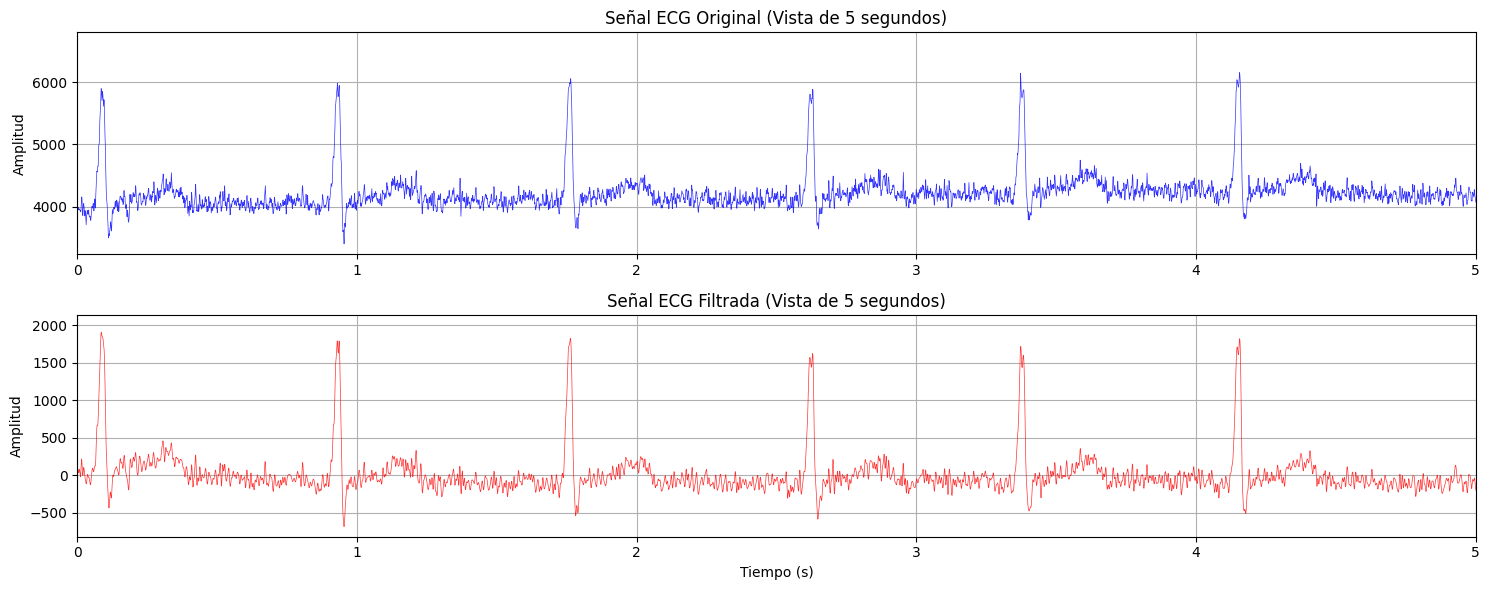

In [4]:
# Aumentar el ancho de la figura a 15 pulgadas
plt.figure(figsize=(15, 6))

plt.subplot(2, 1, 1)
# Añadir linewidth más delgado y alpha para transparencia
plt.plot(t, senal_original, color='blue', linewidth=0.5, alpha=0.8)
plt.title("Señal ECG Original (Vista de 5 segundos)")
plt.ylabel("Amplitud")
# Limitar el eje X para ver solo los primeros 5 segundos
plt.xlim(0, 5) 
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(t_filtrada, senal_filtrada, color='red', linewidth=0.5, alpha=0.8)
plt.title("Señal ECG Filtrada (Vista de 5 segundos)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
# Limitar el eje X al mismo rango para poder compararlas directamente
plt.xlim(0, 5) 
plt.grid(True)

plt.tight_layout()
plt.show()

A partir de las dos señales podemos observar:

- Una amplitud corregida en la señal ECG filtrada, ya que para la original se encontraba en un eje desplazado (4000) y llega a picos de 6000, en cambio la señal filtrada esta centrada en cero, esto puede sugerir que se realizó un filtrado por pasa altas 

Métricas del Ciclo Cardíaco (Señal Original):
Promedio (Offset DC): 4198.21
Valor RMS: 4208.69
Varianza: 88096.03
Desviación Estándar: 296.81


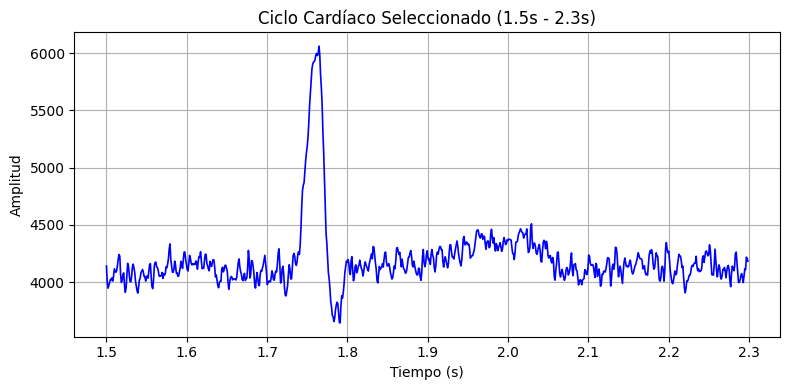

In [5]:

t_inicio = 1.5
t_fin = 2.3
Fs = 1024

idx_inicio = int(t_inicio * Fs)
idx_fin = int(t_fin * Fs)

ciclo_cardiaco = senal_original[idx_inicio:idx_fin]
t_ciclo = t[idx_inicio:idx_fin]

promedio = np.mean(ciclo_cardiaco)
valor_rms=rms(ciclo_cardiaco)
varianza = np.var(ciclo_cardiaco)
desviacion_std = np.std(ciclo_cardiaco)

print("Métricas del Ciclo Cardíaco (Señal Original):")
print(f"Promedio (Offset DC): {promedio:.2f}")
print(f"Valor RMS: {valor_rms:.2f}")
print(f"Varianza: {varianza:.2f}")
print(f"Desviación Estándar: {desviacion_std:.2f}")

plt.figure(figsize=(8, 4))
plt.plot(t_ciclo, ciclo_cardiaco, color='blue', linewidth=1.2)
plt.title("Ciclo Cardíaco Seleccionado (1.5s - 2.3s)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid(True)
plt.tight_layout()
plt.show()

- El promedio significa los valores de amplitud entre el total de muestras, asi las cosas, observamos como tiene un nivel DC elevado en aproximadamente 4200, esto se puede deber a el voltaje entre los electrodos y la piel.

- El valor RMS equivale a la potencia total de nuestra señal el valor de 4208 es similar al promedio de la señal, es decir, que no vemos el verdadero valor del RMS por la interferencia de la línea base.

- La varianza mide la dispersión de los datos respecto a la media, el valor (88096) es muy elevado, por que tenemos el pico que llega hasta una amplitud de 6000 el cual elevado al cuadrado y sumado con los otros datos deriva en este valor.  

- La desviación estándar es la raíz cuadrada de la varianza, nos entrega el valor mas acertado, pues no es afecto por el desplazamiento DC de la señal.


Métricas del Ciclo Cardíaco (Señal Original):
Promedio (Offset DC): -5.99
Valor RMS: 294.62
Varianza: 86764.69
Desviación Estándar: 294.56


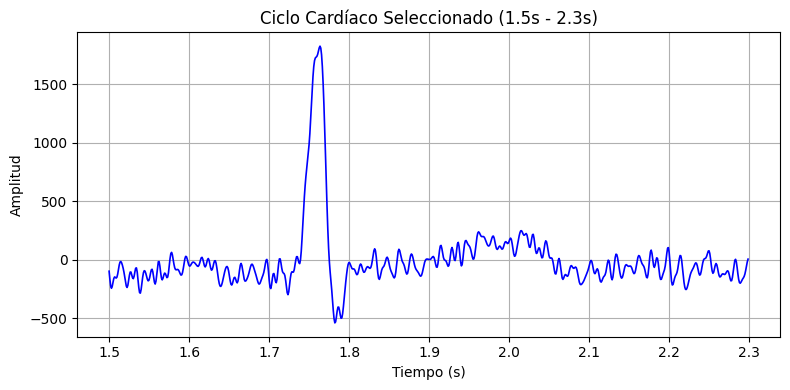

In [6]:
t_inicio = 1.5
t_fin = 2.3
Fs = 1024

idx_inicio = int(t_inicio * Fs)
idx_fin = int(t_fin * Fs)

ciclo_cardiaco = senal_filtrada[idx_inicio:idx_fin]
t_ciclo = t[idx_inicio:idx_fin]

promedio = np.mean(ciclo_cardiaco)
valor_rms=rms(ciclo_cardiaco)
varianza = np.var(ciclo_cardiaco)
desviacion_std = np.std(ciclo_cardiaco)

print("Métricas del Ciclo Cardíaco (Señal Original):")
print(f"Promedio (Offset DC): {promedio:.2f}")
print(f"Valor RMS: {valor_rms:.2f}")
print(f"Varianza: {varianza:.2f}")
print(f"Desviación Estándar: {desviacion_std:.2f}")

plt.figure(figsize=(8, 4))
plt.plot(t_ciclo, ciclo_cardiaco, color='blue', linewidth=1.2)
plt.title("Ciclo Cardíaco Seleccionado (1.5s - 2.3s)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid(True)
plt.tight_layout()
plt.show()

## Comparación:

- Se puede observar como disminuyó el valor promedio para la señal filtrada, pasó de 4198 a -6, esto gracias a la corrección del nivel DC que movió la señal a 0 en el eje X.

- En el valor RMS también se observa un cambio representativo pasando de 4208.69 a 294.62 en la señal filtrada, esto ocurre por la corrección del nivel DC, llevando a que la señal tenga una menor amplitud, este nuevo valor representa la energía electrica producida por el ciclo cardiaco.

- La varianza no se ve afectada, no hay mayores cambios, pues los datos sean filtrados o no estan igual de dispersos.

- La desviación estándar como dijimos mide la amplitud de la señal, así que se supone no debe cambiar, y así pasó, por consiguiente nos mide el valor real del complejo QRS antes y después de filtrada.

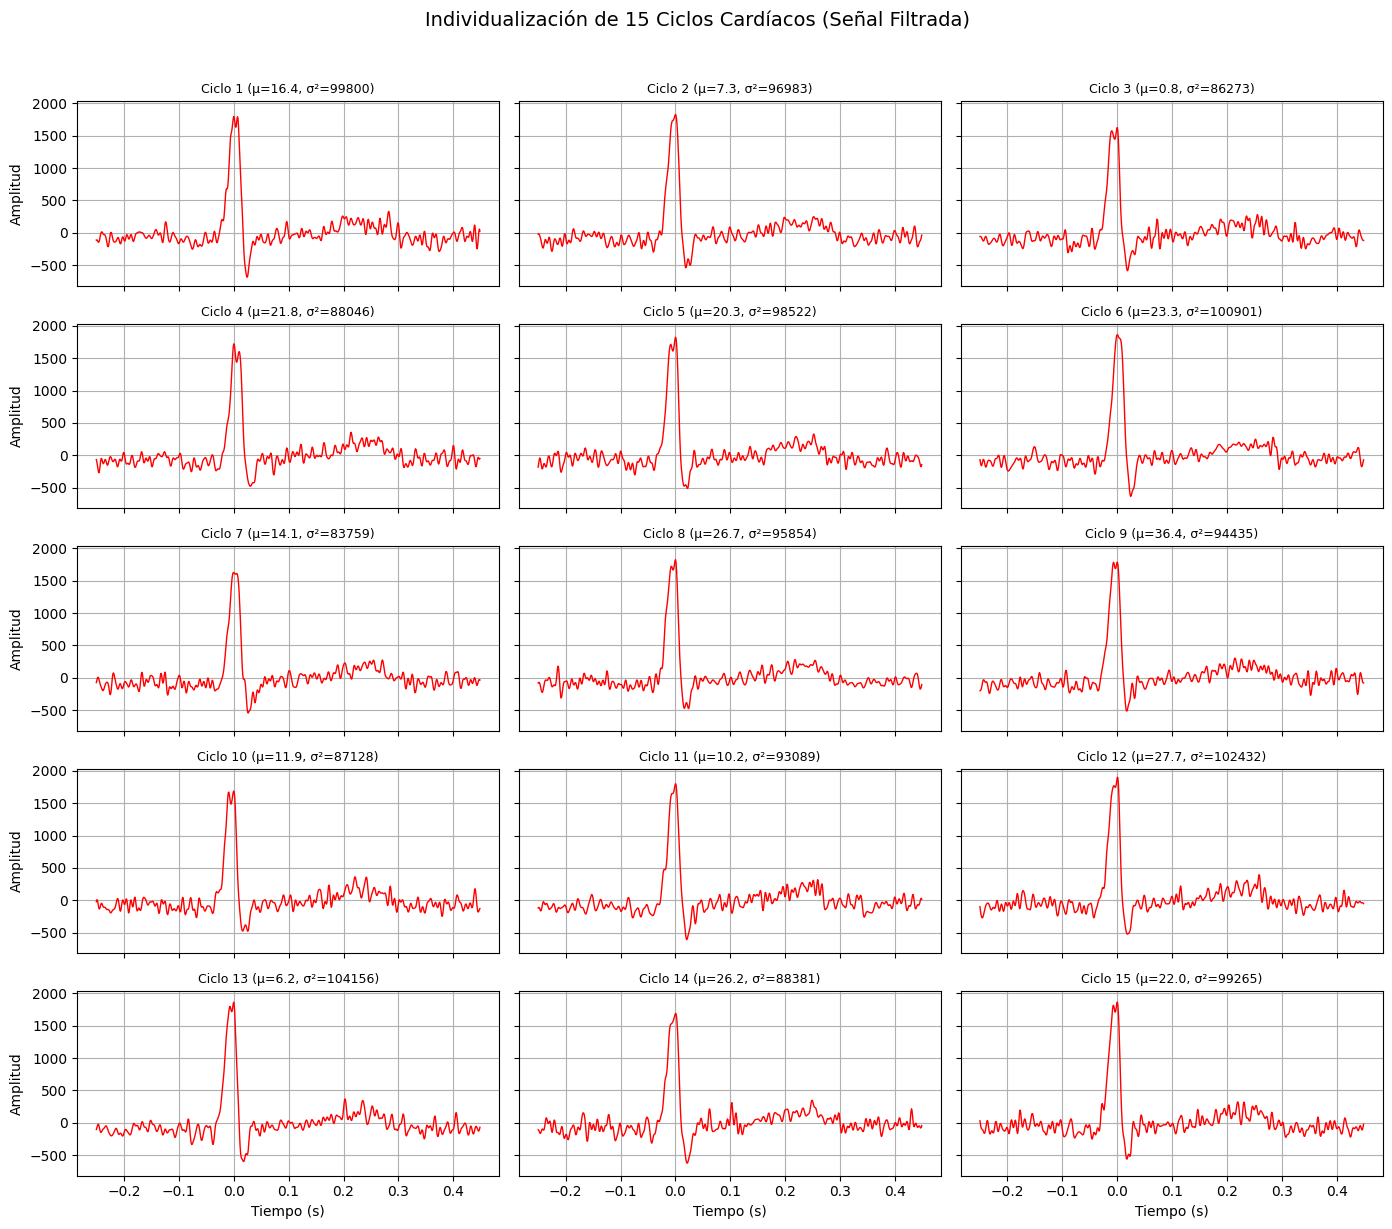

Ciclo    | Promedio     | Varianza
-----------------------------------
1        | 16.37        | 99799.75
2        | 7.29         | 96982.76
3        | 0.80         | 86273.30
4        | 21.78        | 88046.29
5        | 20.32        | 98521.65
6        | 23.28        | 100900.99
7        | 14.08        | 83759.12
8        | 26.70        | 95854.29
9        | 36.38        | 94434.78
10       | 11.94        | 87127.75
11       | 10.20        | 93089.44
12       | 27.74        | 102432.25
13       | 6.19         | 104155.52
14       | 26.21        | 88380.59
15       | 21.97        | 99264.76


In [ ]:
# 1. Detección y selección de picos R válidos
distancia_minima = int(0.6 * Fs)
picos, _ = find_peaks(senal_filtrada, height=1000, distance=distancia_minima)

vent_antes = int(0.25 * Fs)
vent_despues = int(0.45 * Fs)

picos_validos = [
    p for p in picos 
    if (p - vent_antes >= 0) and (p + vent_despues < len(senal_filtrada))
][:15]

t_relativo = np.arange(-vent_antes, vent_despues) / Fs

# Listas para almacenar datos
lista_ciclos = []
promedios = []
varianzas = []

# 2. Crear figura con 15 subplots (5 filas x 3 columnas)
fig, axes = plt.subplots(5, 3, figsize=(14, 12), sharex=True, sharey=True)
axes_flat = axes.flatten()

for i, pico in enumerate(picos_validos):
    ciclo = senal_filtrada[pico - vent_antes : pico + vent_despues]
    
    # Guardar ciclo y métricas
    lista_ciclos.append(ciclo)
    mean_val = np.mean(ciclo)
    var_val = np.var(ciclo)
    promedios.append(mean_val)
    varianzas.append(var_val)
    
    # Graficar en el subplot correspondiente
    ax = axes_flat[i]
    ax.plot(t_relativo, ciclo, color='red', linewidth=1)
    ax.set_title(f"Ciclo {i+1} (µ={mean_val:.1f}, σ²={var_val:.0f})", fontsize=9)
    ax.grid(True)

# Configurar etiquetas compartidas en los bordes para evitar sobreposición
for ax in axes[-1, :]:
    ax.set_xlabel("Tiempo (s)")
for ax in axes[:, 0]:
    ax.set_ylabel("Amplitud")

plt.suptitle("15 Ciclos Cardíacos (Señal Filtrada)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# 3. Mostrar la tabla de resultados
print(f"{'Ciclo':<8} | {'Promedio':<12} | {'Varianza'}")
print("-" * 35)
for i in range(15):
    print(f"{i+1:<8} | {promedios[i]:<12.2f} | {varianzas[i]:.2f}")

- De acuerdo a las gráficas a priori se podría considerar que la señal es estacionaria, pues, se evidencia como cada ciclo es muy similar y tiene un igual comportamiento a través del tiempo, sin embargo cuando revisamos los valores de promedio y varianza se evidencian leves variaciones que indican que estas señales si se diferencian en cuanto a su amplitud, por consiguiente la señal es no estacionaria.

In [9]:
distancia_minima = int(0.6 * Fs)
picos, _ = find_peaks(senal_filtrada, height=1000, distance=distancia_minima)

vent_antes = int(0.25 * Fs)
vent_despues = int(0.45 * Fs)

# Filtrar picos válidos (que no estén en los bordes)
picos_validos = []
for p in picos:
    if (p - vent_antes >= 0) and (p + vent_despues < len(senal_filtrada)):
        picos_validos.append(p)

# Seleccionar 15 picos
picos_validos = picos_validos[:15]

# --- AQUÍ DEFINIMOS LA LISTA PARA GUARDAR LOS CICLOS ---
lista_ciclos = [] 

for pico in picos_validos:
    # Extraer el fragmento del ciclo
    ciclo = senal_filtrada[pico - vent_antes : pico + vent_despues]
    # Guardar el ciclo en nuestra lista
    lista_ciclos.append(ciclo)

# 2. Función para el análisis estadístico
def comparar_ciclos(ciclo_A, ciclo_B, nombre_A, nombre_B):
    print(f"\n--- Comparación: {nombre_A} vs {nombre_B} ---")
    
    # Prueba de Normalidad (Shapiro-Wilk)
    _, p_norm_A = stats.shapiro(ciclo_A)
    _, p_norm_B = stats.shapiro(ciclo_B)
    normalidad = (p_norm_A > 0.05) and (p_norm_B > 0.05)
    
    print(f"Normalidad {nombre_A}: p={p_norm_A:.4f}")
    print(f"Normalidad {nombre_B}: p={p_norm_B:.4f}")
    
    # Prueba de Homocedasticidad (Levene)
    _, p_levene = stats.levene(ciclo_A, ciclo_B)
    homocedasticidad = p_levene > 0.05
    print(f"Homocedasticidad (Levene): p={p_levene:.4f}")
    
    # Toma de decisión y Prueba de Medias
    print("Resultados de los supuestos:")
    if normalidad and homocedasticidad:
        print("Cumple normalidad y homocedasticidad. Se procede con Prueba T (t-test).")
        stat, p_test = stats.ttest_ind(ciclo_A, ciclo_B)
        nombre_prueba = "Prueba t de Student"
    else:
        print("NO cumple los supuestos (Normalidad o Homocedasticidad). Se procede con Prueba U de Mann-Whitney.")
        stat, p_test = stats.mannwhitneyu(ciclo_A, ciclo_B, alternative='two-sided')
        nombre_prueba = "Prueba U de Mann-Whitney"
        
    print(f"\nResultado final ({nombre_prueba}): p-valor = {p_test:.4f}")
    
    if p_test > 0.05:
        print("Conclusión: NO hay diferencia estadística significativa entre los ciclos.")
    else:
        print("Conclusión: SÍ hay diferencia estadística significativa entre los ciclos.")

# 3. Realizar las comparaciones usando la lista que acabamos de llenar
# (En Python, el índice 0 es el Ciclo 1, el índice 1 es el Ciclo 2, etc.)
comparar_ciclos(lista_ciclos[0], lista_ciclos[1], "Ciclo 1", "Ciclo 2")
comparar_ciclos(lista_ciclos[0], lista_ciclos[14], "Ciclo 1", "Ciclo 15")


--- Comparación: Ciclo 1 vs Ciclo 2 ---
Normalidad Ciclo 1: p=0.0000
Normalidad Ciclo 2: p=0.0000
Homocedasticidad (Levene): p=0.8781
Resultados de los supuestos:
NO cumple los supuestos (Normalidad o Homocedasticidad). Se procede con Prueba U de Mann-Whitney.

Resultado final (Prueba U de Mann-Whitney): p-valor = 0.2181
Conclusión: NO hay diferencia estadística significativa entre los ciclos.

--- Comparación: Ciclo 1 vs Ciclo 15 ---
Normalidad Ciclo 1: p=0.0000
Normalidad Ciclo 15: p=0.0000
Homocedasticidad (Levene): p=0.8822
Resultados de los supuestos:
NO cumple los supuestos (Normalidad o Homocedasticidad). Se procede con Prueba U de Mann-Whitney.

Resultado final (Prueba U de Mann-Whitney): p-valor = 0.4422
Conclusión: NO hay diferencia estadística significativa entre los ciclos.


In [12]:
def probar_estacionariedad_adf(senal, nombre_senal="Señal"):
    print(f"=== Prueba de Dickey-Fuller Aumentada: {nombre_senal} ===")
    
    # Ejecución del test ADF
    resultado = adfuller(senal)
    
    estadistico_adf = resultado[0]
    p_valor = resultado[1]
    lags_usados = resultado[2]
    valores_criticos = resultado[4]
    
    print(f"Estadístico ADF: {estadistico_adf:.4f}")
    print(f"p-valor: {p_valor:.4e}")
    print(f"Retardos utilizados: {lags_usados}")
    print("Valores críticos:")
    for nivel, valor in valores_criticos.items():
        print(f"   {nivel}: {valor:.4f}")
        
    # Toma de decisión
    if p_valor < 0.05:
        print(f"\nResultado (p < 0.05): Se rechaza la hipótesis nula (H0).")
        print(f"--> La {nombre_senal} es estacionaria.")
    else:
        print(f"\nResultado (p >= 0.05): se acepta la hipótesis nula (H0).")
        print(f"--> La {nombre_senal} es no estacionaria.")
    print("-" * 55)

# Probar la prueba ADF en ambas señales para comparar
probar_estacionariedad_adf(senal_original, "Señal Original")
probar_estacionariedad_adf(senal_filtrada, "Señal Filtrada")

=== Prueba de Dickey-Fuller Aumentada: Señal Original ===
Estadístico ADF: -16.4432
p-valor: 2.4170e-29
Retardos utilizados: 51
Valores críticos:
   1%: -3.4306
   5%: -2.8616
   10%: -2.5668

Resultado (p < 0.05): Se rechaza la hipótesis nula (H0).
--> La Señal Original es estacionaria.
-------------------------------------------------------
=== Prueba de Dickey-Fuller Aumentada: Señal Filtrada ===
Estadístico ADF: -26.6125
p-valor: 0.0000e+00
Retardos utilizados: 19
Valores críticos:
   1%: -3.4306
   5%: -2.8616
   10%: -2.5668

Resultado (p < 0.05): Se rechaza la hipótesis nula (H0).
--> La Señal Filtrada es estacionaria.
-------------------------------------------------------
